## Analytic Gaussian $P_4$ Bond Information ##

This notebook will generate figure 3a in the report; this is the figure analysing the values of the Bond Information for the 4-element path graph $P_4$ in the Gaussian case, for which the Tsallis-Alpha has an analytic expression and we can calculate the Bond Information analytically. After producing the figure, the x-axis labelling and table were created in Inkscape.

In [1]:
import networkx as nx
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from Modules.brute_force_bond_finder import brute_force_bond_finder
from Modules.gaussian_BI import covariance_matrix_bond, analytic_gaussian_bi, bond_nonbond_list_maker, factorised_bi, bond_to_label
from Modules.moebius_machinery import mat_vec_solve_mu

In [2]:
P_4 = nx.path_graph(4)
bond_facts, nonbond_facts = factorised_bi(P_4, brute_force_bond_finder, 0.99)

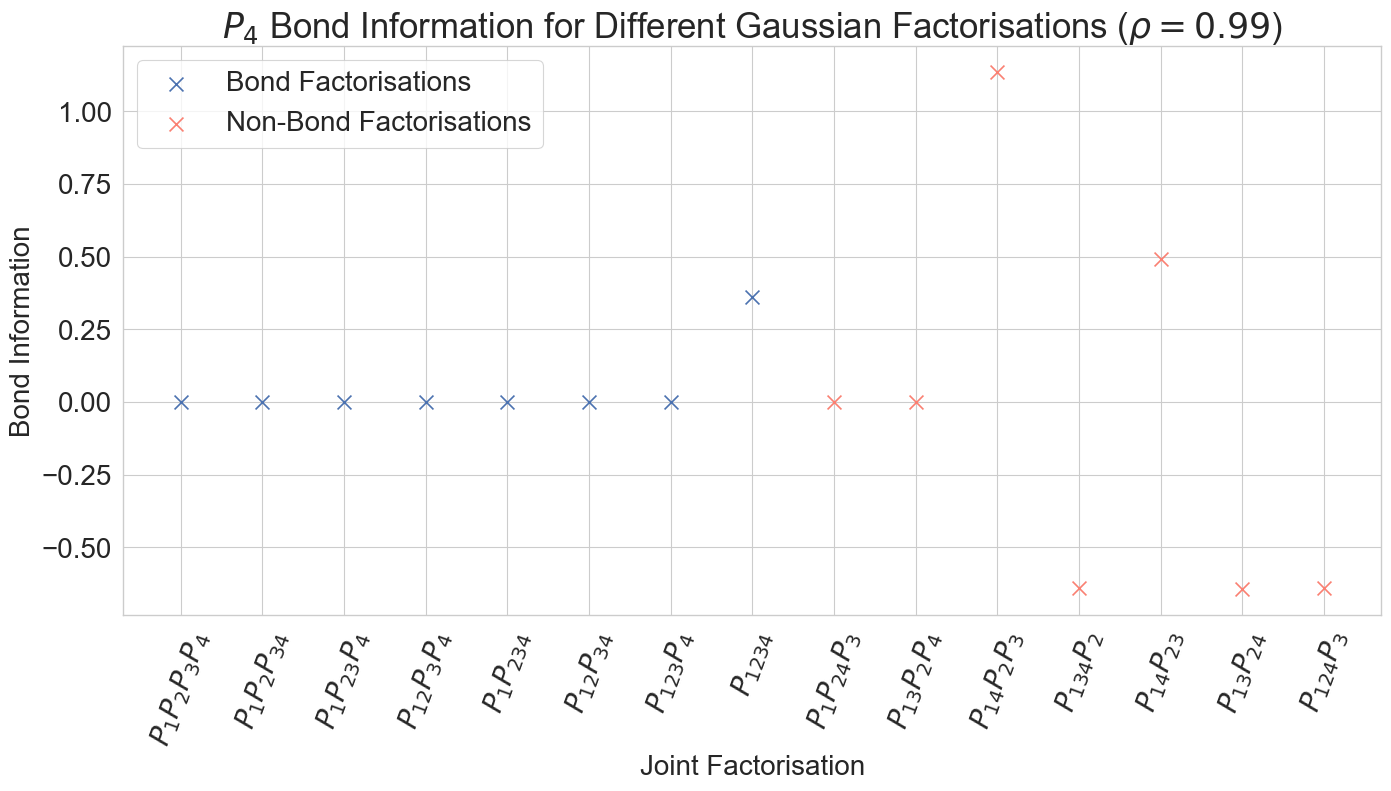

In [4]:
# Plotting
sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(14, 8))

x = range(15)

ax.scatter(x[:len(list(bond_facts.values()))], list(bond_facts.values()), marker="x", s=100,
        label="Bond Factorisations")
ax.scatter(x[len(list(bond_facts.values())):], list(nonbond_facts.values()), marker="x", s=100,
        color="salmon", label="Non-Bond Factorisations")

ax.set_xticks(x)

ax.set_xticklabels([bond_to_label(k) for k in (bond_facts).keys()] + 
                   [bond_to_label(k) for k in (nonbond_facts).keys()], rotation=70)
ax.set_ylabel("Bond Information", fontsize=20)
ax.set_xlabel("Joint Factorisation", fontsize=20)
ax.tick_params(labelsize=20)
ax.set_title(r"$P_4$ Bond Information for Different Gaussian Factorisations ($\rho=0.99$)", fontsize=25)
plt.legend(fontsize=20)

plt.tight_layout()
plt.savefig(r"C:\Users\morit\Thesis_Repo\Plots\four_path_bi_gaussian.pdf")